# **Student ID: F534874**

In [9]:

time = "night" # day by default

# store the map with nodes and links including its weight
uni_map = {
    'NFL Pitch':
    {
        'Library': 100,
        'West Park': 70
    },

    'Library':
    {
        'NFL Pitch': 100,
        'West Park': 60,
        'Stem Lab': 40,
        'Haslegrave': 250,
        'EHB': 190
    },

    'Stem Lab':
    {
        'Library': 40,
        'West Park': 20
    },

    'West Park':
    {
        'NFL Pitch': 70,
        'Library': 60,
        'Stem Lab': 20
    },

    'EHB':
    {
        'Library': 190,
        'Haslegrave': 40,
        'James France': 40 # Blocked for construction
    },

    'Haslegrave':
    {
        'EHB': 40,
        'Library': 250,
        'James France': 50,
        'Stewart Mason': 80,
        'Hazel-Rigg': 130
    },

    'James France':
    {
        'Haslegrave': 50,
        'Stewart Mason': 20,
        'EHB': 40, # Blocked for construction
        'The Holt': 170 # Closed at night
    },

    'Stewart Mason':
    {
        'Haslegrave': 80,
        'James France': 20,
        'Powerbase': 200
    },

    'Powerbase':
    {
        'Stewart Mason': 200,
        'The Holt': 350,
        'Hazel-Rigg': 60,
        'Student Union': 70
    },

    'Hazel-Rigg':
    {
        'Powerbase': 60,
        'Haslegrave': 130,
        'Student Union': 15,
        'Hipac': 20
    },

    'Hipac':
    {
        'Hazel-Rigg': 20,
        'Student Union': 25
    },

    'Student Union':
    {
        'Hazel-Rigg': 15,
        'Powerbase': 70,
        'Hipac': 25,
        'Main Road': 25
    },

    'The Holt':
    {
        'James France': 170, # closed at night
        'Powerbase': 350
    },

    'Main Road':
    {
        'Student Union': 25
    }
}

# coordinates for heuristic and map visualistion
coordinates = {
    'NFL Pitch': (0, 10),
    'Library': (1, 9),
    'Stem Lab': (1, 7),
    'West Park': (0.5 , 8),
    'EHB': (2.5, 8.5),
    'Haslegrave': (3, 9.5),
    'James France': (3.3, 7.7),
    'Stewart Mason': (4.2, 7.2),
    'Powerbase': (7, 7.7),
    'Hazel-Rigg': (5, 9.3),
    'Hipac': (5.5, 10),
    'Student Union': (7, 9.3),
    'The Holt': (3.3, 4.7),
    'Main Road': (9, 9)
}

# Blocked Roads
blocked_roads = [
    ('EHB', 'James France')
]

if time == "night":
    blocked_roads = blocked_roads + [
        ('James France', 'The Holt')
    ]





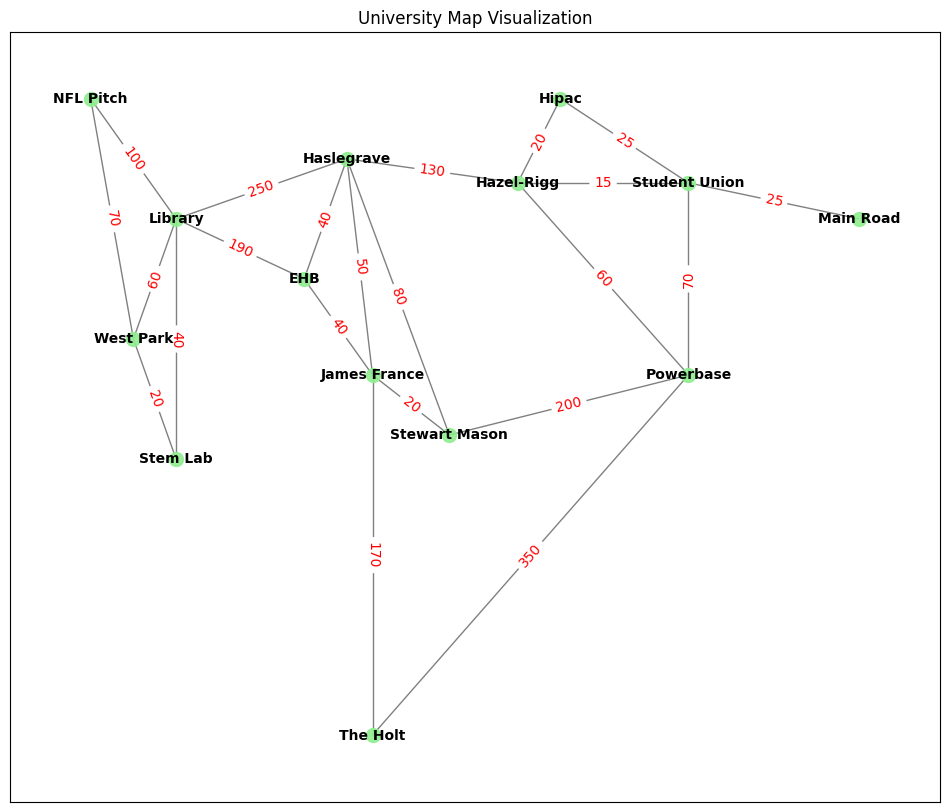

In [10]:
import matplotlib.pyplot as plt
import networkx as nx

# create a graph from the uni_map
G = nx.Graph()
for source, destinations in uni_map.items():
    for destination, distance in destinations.items():
        G.add_edge(source, destination, weight=distance)

# use the provided coordinates for positioning the nodes
pos = coordinates

plt.figure(figsize=(12, 10))

# draw the nodes as small circles/points
nx.draw_networkx_nodes(G, pos, node_color='lightgreen', node_size=100, alpha=0.9)

# draw the edges
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1)

# draw the node labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# draw edge labels (distances)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

plt.title('University Map Visualization')

plt.show()


In [11]:
import math

def heuristic(node, goal):
    # calculate the straight line distance between two nodes
    x1, y1 = pos[node]
    x2, y2 = pos[goal]
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

# test
heuristic('Library', 'Powerbase')

6.139218191268331

In [12]:
import heapq

INITIAL_STATE = "The Holt"
GOAL_STATE = "James France"

def isGOAL(state):
  return state == GOAL_STATE

def ACTIONS(state):
  return uni_map[state].keys()

def setINITIAL(state):
  global INITIAL_STATE
  INITIAL_STATE = state
  return INITIAL_STATE

def setGOAL(state):
  global GOAL_STATE
  GOAL_STATE = state
  return GOAL_STATE

def aStarSearch(initial_state, goal_state):
  setINITIAL(initial_state)
  setGOAL(goal_state)


  node_state = INITIAL_STATE
  node_path = [INITIAL_STATE]
  node_g = 0 #g(n)
  node_h = heuristic(INITIAL_STATE, GOAL_STATE) #h(n)
  node_f = node_g + node_h #f = h(n) + g(n)

  if isGOAL(node_state):
    return node_path

  # fronter - a priority queue order by f
  frontier = []
  heapq.heappush(frontier, (node_f, node_g, node_state, node_path) )
  print("Frontier", [(f, g, s) for f, g, s, p in frontier])

  explored = set()

  while True:
    if len(frontier) == 0:
      return None

    node_f, node_g, node_state, node_path = heapq.heappop(frontier)

    if isGOAL(node_state):
      return node_path

    explored.add(node_state)

    # for each action in ACTIONS(state)
    for action in ACTIONS(node_state):
      child_state = action
      child_path = node_path + [child_state]

      # skip blocked roads
      if (node_state, child_state) in blocked_roads or (child_state, node_state) in blocked_roads:
        print(node_state, "to", child_state, "is blocked")
        continue

      child_g = node_g + uni_map[node_state][child_state]
      child_h = heuristic(child_state, GOAL_STATE)
      child_f = child_g + child_h

      in_frontier = False
      for f, g, state, path in frontier:
        if state == child_state:
          in_frontier = True
          break

      if child_state not in explored and not in_frontier:
        heapq.heappush(frontier, (child_f, child_g, child_state, child_path))
        print("Frontier", [(f, g, s) for f, g, s, p in frontier])

#this function takes in 3 nodes
def aStarSearchW(initial_state, waypoint, goal_state):
  setINITIAL(initial_state)
  setGOAL(goal_state)
  firstPath = []
  secondPath =[]
  # if way point is 0, just do 1 a star search with initial and goal
  if waypoint == "0":
    firstPath = aStarSearch(initial_state, goal_state)
    print("The path to take is", firstPath)
  else:
    firstPath = aStarSearch(initial_state, waypoint)
    secondPath = aStarSearch(waypoint, goal_state)
    print("The path to take is", firstPath + secondPath[1:]) # so that the waypoint isnt repeated

#test
aStarSearchW("The Holt", "Library", "James France")



Frontier [(4.876474136094643, 0, 'The Holt')]
The Holt to James France is blocked
Frontier [(356.13921819126836, 350, 'Powerbase')]
Frontier [(553.6715119501372, 550, 'Stewart Mason')]
Frontier [(414.01123422402634, 410, 'Hazel-Rigg'), (553.6715119501372, 550, 'Stewart Mason')]
Frontier [(414.01123422402634, 410, 'Hazel-Rigg'), (553.6715119501372, 550, 'Stewart Mason'), (426.0074953183502, 420, 'Student Union')]
Frontier [(426.0074953183502, 420, 'Student Union'), (553.6715119501372, 550, 'Stewart Mason'), (542.0615528128088, 540, 'Haslegrave')]
Frontier [(426.0074953183502, 420, 'Student Union'), (434.6097722286464, 430, 'Hipac'), (542.0615528128088, 540, 'Haslegrave'), (553.6715119501372, 550, 'Stewart Mason')]
Frontier [(434.6097722286464, 430, 'Hipac'), (453.0, 445, 'Main Road'), (542.0615528128088, 540, 'Haslegrave'), (553.6715119501372, 550, 'Stewart Mason')]
Frontier [(553.6715119501372, 550, 'Stewart Mason'), (581.5811388300842, 580, 'EHB')]
Frontier [(553.6715119501372, 550, '